In [47]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from scipy.cluster.hierarchy import (linkage, dendrogram, cut_tree)
import datetime
import os
os.chdir('/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8')
os.getcwd()

'/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 8'

In [48]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm
from statsmodels.tsa.exponential_smoothing.ets import ETSModel as ets
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path

In [49]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                        summarize,
                        contrast)
from ISLP import confusion_table
#from ISLP.models import contrast
from ISLP.bart import BART
from ISLP.cluster import compute_linkage

In [50]:
from sklearn.discriminant_analysis import \
                        (LinearDiscriminantAnalysis as LDA,
                        QuadraticDiscriminantAnalysis as QDA)
from sklearn import datasets
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import \
                            (mean_squared_error as myMSE, 
                            accuracy_score, 
                            classification_report, 
                            confusion_matrix)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (GradientBoostingRegressor, 
                                BaggingClassifier,
                                RandomForestClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (KMeans, AgglomerativeClustering)

In [51]:
dfTrain = pd.read_csv('train.csv',
                     parse_dates = True,
                     low_memory = False,
                     index_col = 'date')
dfTest = pd.read_csv('test.csv')
dfStores = pd.read_csv('stores.csv')
dfOil = pd.read_csv('oil.csv')
dfHolidays = pd.read_csv('holidays_events.csv')
dfTrans = pd.read_csv('transactions.csv')

In [52]:
dfTrain.index

DatetimeIndex(['2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01',
               ...
               '2017-08-15', '2017-08-15', '2017-08-15', '2017-08-15',
               '2017-08-15', '2017-08-15', '2017-08-15', '2017-08-15',
               '2017-08-15', '2017-08-15'],
              dtype='datetime64[ns]', name='date', length=3000888, freq=None)

In [53]:
print('Shapes of dataframes')
print('--------------------')
print('dfTrain: ', dfTrain.shape)
print('dfTest: ', dfTest.shape)
print('dfStores: ', dfStores.shape)
print('dfOil: ', dfOil.shape)
print('dfHol', dfHolidays.shape)

Shapes of dataframes
--------------------
dfTrain:  (3000888, 5)
dfTest:  (28512, 5)
dfStores:  (54, 5)
dfOil:  (1218, 2)
dfHol (350, 6)


In [54]:
dfTrain.columns

Index(['id', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [55]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   store_nbr    int64  
 2   family       object 
 3   sales        float64
 4   onpromotion  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [56]:
dfTrain.head(12)

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0
2013-01-01,5,1,BREAD/BAKERY,0.0,0
2013-01-01,6,1,CELEBRATION,0.0,0
2013-01-01,7,1,CLEANING,0.0,0
2013-01-01,8,1,DAIRY,0.0,0


In [57]:
dfTest

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [58]:
dfTrain.isnull().sum()

id             0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

#### No null values

### Add Month, Day, and Year columns to dfTrain.

In [59]:
# Add columns
dfTrain['Year'] = dfTrain.index.year
dfTrain['Month'] = dfTrain.index.month
dfTrain['Day'] = dfTrain.index.day

In [60]:
dfTrain['sales'] = dfTrain.pop('sales')    # Move to last column

### Merge dfTrain and dfStores

In [61]:
dfTrainStores = dfTrain.merge(dfStores, on = 'store_nbr',
                            how = 'left')

#### Merged two dataframes for more data

In [62]:
dfTrain

,id,store_nbr,family,onpromotion,Year,Month,Day,sales
date,,,,,,,,
2013-01-01,0,1,AUTOMOTIVE,0,2013,1,1,0.000
2013-01-01,1,1,BABY CARE,0,2013,1,1,0.000
2013-01-01,2,1,BEAUTY,0,2013,1,1,0.000
2013-01-01,3,1,BEVERAGES,0,2013,1,1,0.000
2013-01-01,4,1,BOOKS,0,2013,1,1,0.000
...,...,...,...,...,...,...,...,...
2017-08-15,3000883,9,POULTRY,0,2017,8,15,438.133
2017-08-15,3000884,9,PREPARED FOODS,1,2017,8,15,154.553
2017-08-15,3000885,9,PRODUCE,148,2017,8,15,2419.729


In [63]:
dfTrainStores

,id,store_nbr,family,onpromotion,Year,Month,Day,sales,city,state,type,cluster
0,0,1,AUTOMOTIVE,0,2013,1,1,0.000,Quito,Pichincha,D,13
1,1,1,BABY CARE,0,2013,1,1,0.000,Quito,Pichincha,D,13
2,2,1,BEAUTY,0,2013,1,1,0.000,Quito,Pichincha,D,13
3,3,1,BEVERAGES,0,2013,1,1,0.000,Quito,Pichincha,D,13
4,4,1,BOOKS,0,2013,1,1,0.000,Quito,Pichincha,D,13
...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,9,POULTRY,0,2017,8,15,438.133,Quito,Pichincha,B,6
3000884,3000884,9,PREPARED FOODS,1,2017,8,15,154.553,Quito,Pichincha,B,6
3000885,3000885,9,PRODUCE,148,2017,8,15,2419.729,Quito,Pichincha,B,6
3000886,3000886,9,SCHOOL AND OFFICE SUPPLIES,8,2017,8,15,121.000,Quito,Pichincha,B,6


In [64]:
dfTest

,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0
...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9


In [65]:
dfStores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [66]:
dfStores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

# Exploratory data analysis

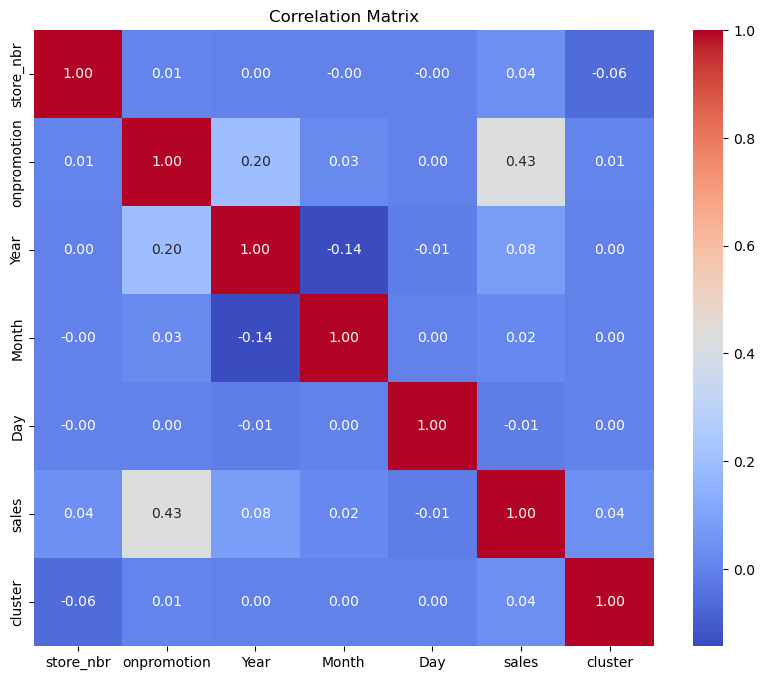

In [67]:
# Correlation matrix
numMatrix = dfTrainStores.select_dtypes(exclude = ['object']).drop(columns = 'id')
correlation_matrix = numMatrix.corr() # Compute correlations
plt.figure(figsize=(10, 8)) # Adjust figure size
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()

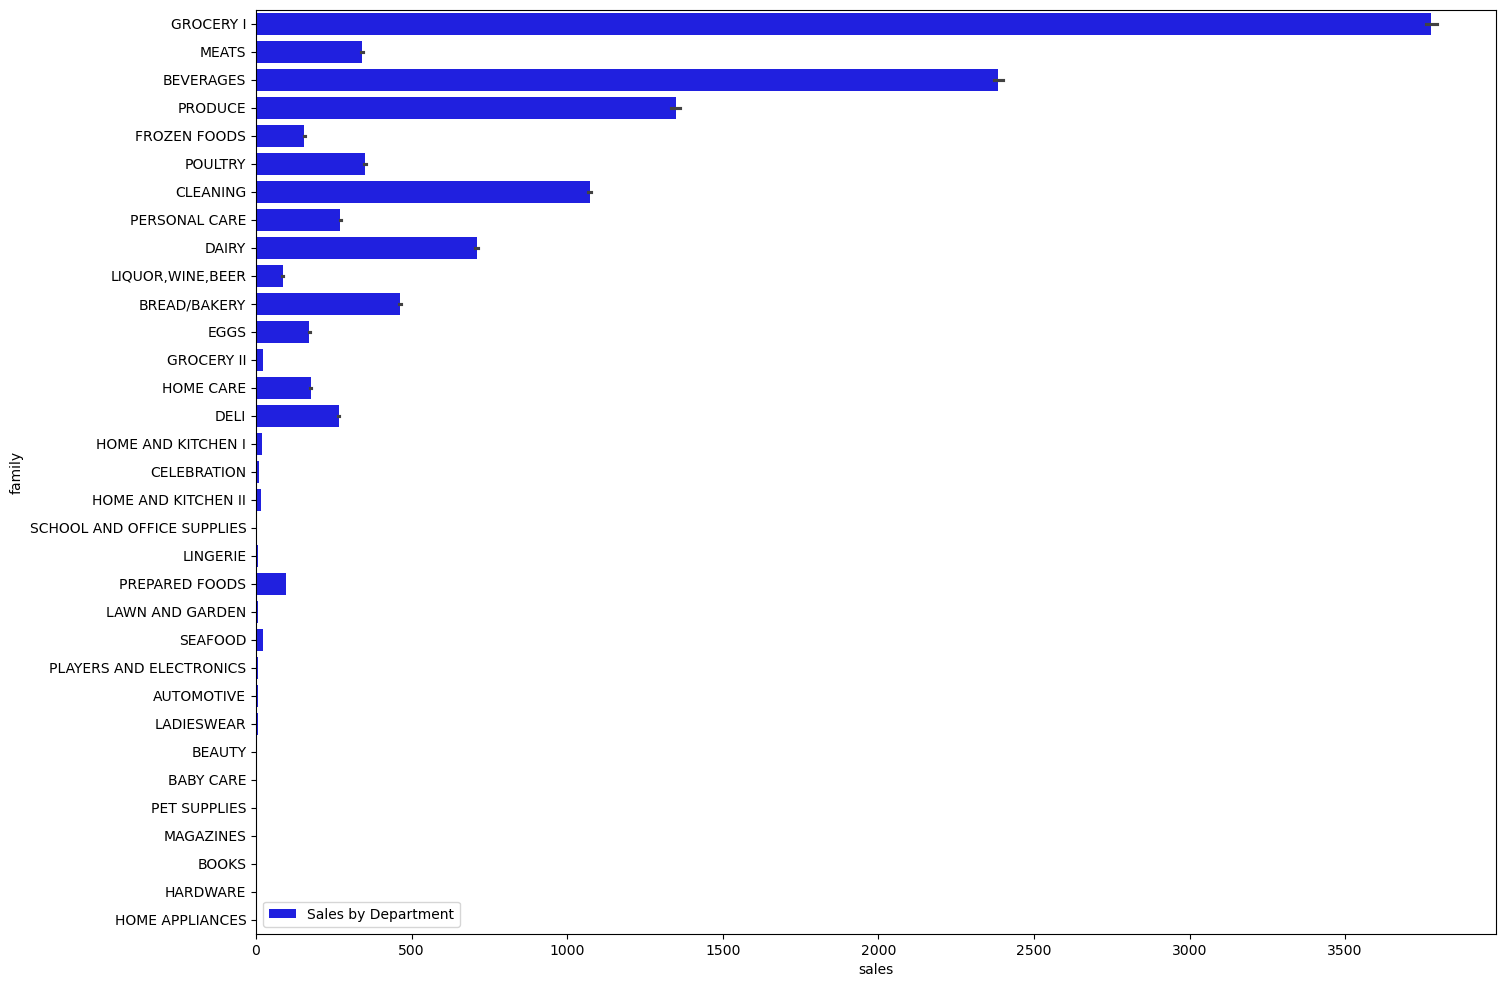

In [68]:
# Sales by Family
plt.figure(figsize = (16,12))
sns.barplot(x = 'sales',
           y = 'family',
           data = dfTrainStores.sort_values(by = ['sales', 'family'], ascending = False),
           label = 'Sales by Department',
           color = 'blue')
plt.show()

#### Highest sales, by a great deal, was groceries, followed by beverages

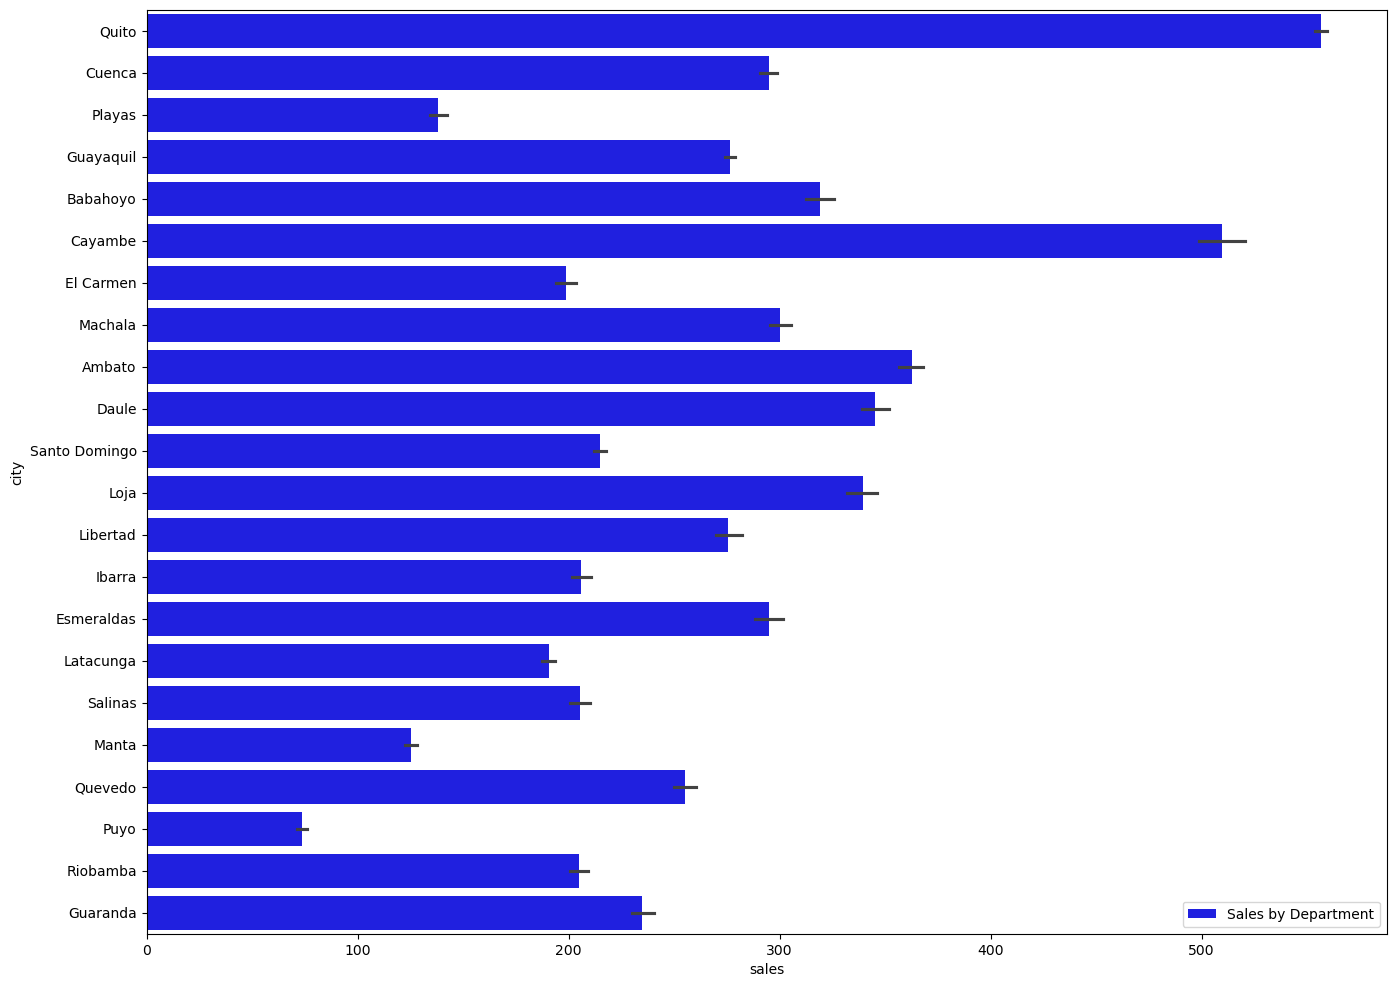

In [69]:
# Sales by City
plt.figure(figsize = (16,12))
sns.barplot(x = 'sales',
           y = 'city',
           data = dfTrainStores.sort_values(by = ['sales', 'family'], ascending = False),
           label = 'Sales by Department',
           color = 'blue')
plt.show()

#### Highest sales was in Quito, followed closely by Cayambe

<Axes: title={'center': 'Sales'}, xlabel='date'>

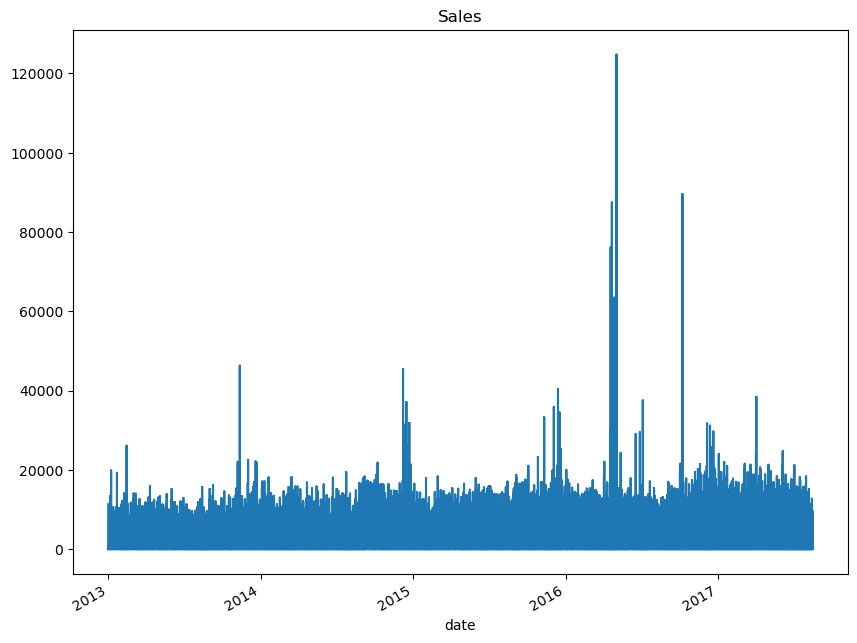

In [70]:
# Overall sales by date over time
dfTrain['sales'].plot(title = 'Sales', figsize = (10,8))

<Figure size 2400x1800 with 0 Axes>

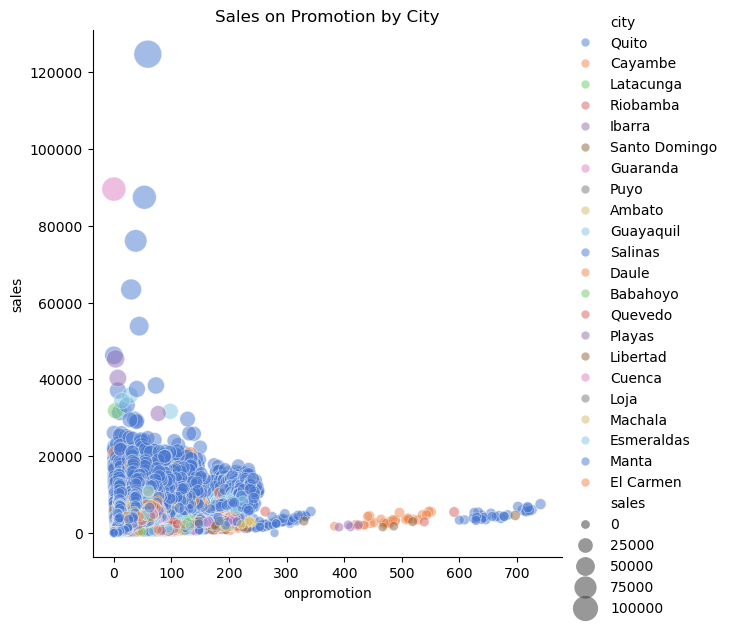

In [71]:
plt.figure(figsize=(24,18))
sns.relplot(x = "onpromotion",
            y = "sales",
            hue = "city",
            size = "sales",
            sizes = (40, 400),
            alpha = 0.5,
            palette = "muted",
            height = 6,
            data = dfTrainStores)
plt.title('Sales on Promotion by City')
plt.show()

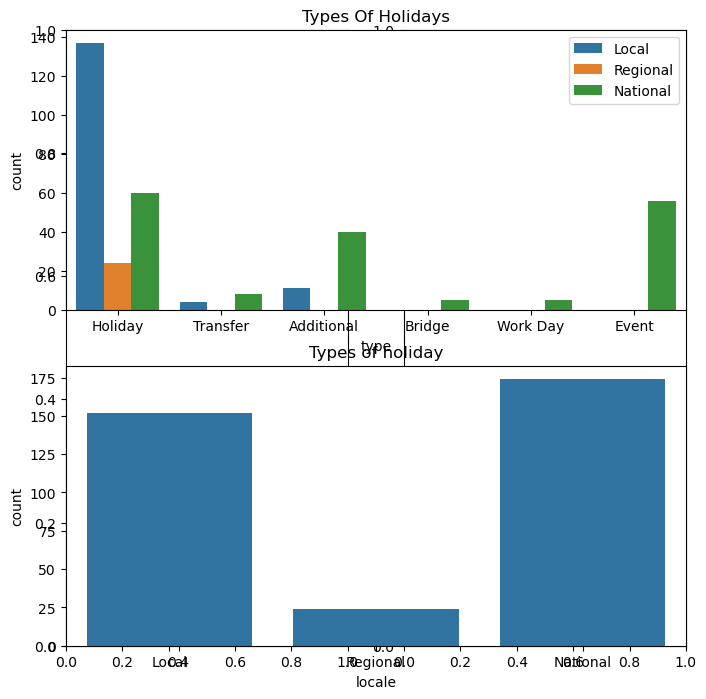

In [72]:
plt.subplots(1, 2, figsize = (8, 8))
plt.subplot(211)
plt.title('Types Of Holidays')
sns.countplot(x = dfHolidays.type, hue = dfHolidays.locale)
plt.legend(loc = 'upper right')
plt.subplot(212)
plt.title('Types of holiday')
sns.countplot(x = dfHolidays.locale)
plt.show()

In [73]:
dfHolidays.groupby(['type','locale']).head(100)
print('Types: ', dfHolidays.type.unique())
print('Locales: ', dfHolidays.locale.unique())

Types:  ['Holiday' 'Transfer' 'Additional' 'Bridge' 'Work Day' 'Event']
Locales:  ['Local' 'Regional' 'National']


In [74]:
state_dates = dfHolidays[((dfHolidays.locale == 'National') |
                        (dfHolidays.locale == 'Regional') &
                        (dfHolidays.type == 'Holiday'))].loc[:, 'date'].values

state = pd.DataFrame({'holiday': 'state_holiday',
                      'd': pd.to_datetime(state_dates)})
holidays = state      
holidays.head()

,holiday,d
0,state_holiday,2012-04-01
1,state_holiday,2012-06-25
2,state_holiday,2012-08-10
3,state_holiday,2012-10-09
4,state_holiday,2012-10-12


In [75]:
print('Autocorrelaction: ', dfTrain['sales'].autocorr())

Autocorrelaction:  -0.02416951089167313


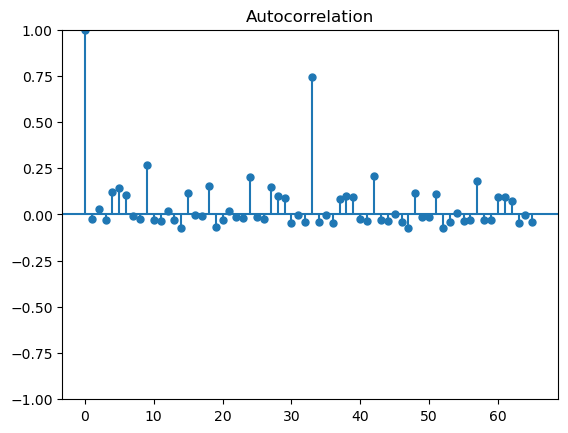

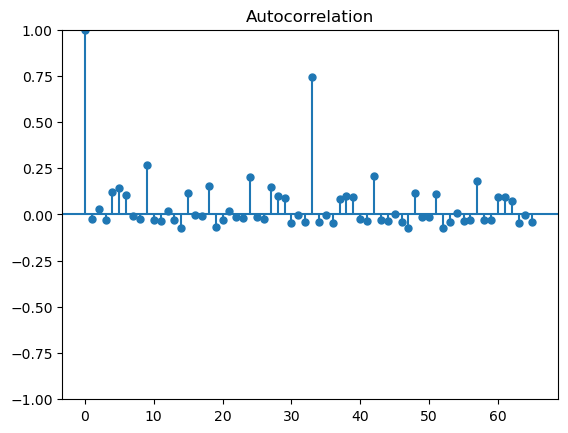

In [76]:
plot_acf(dfTrain['sales'], alpha = 0.05)

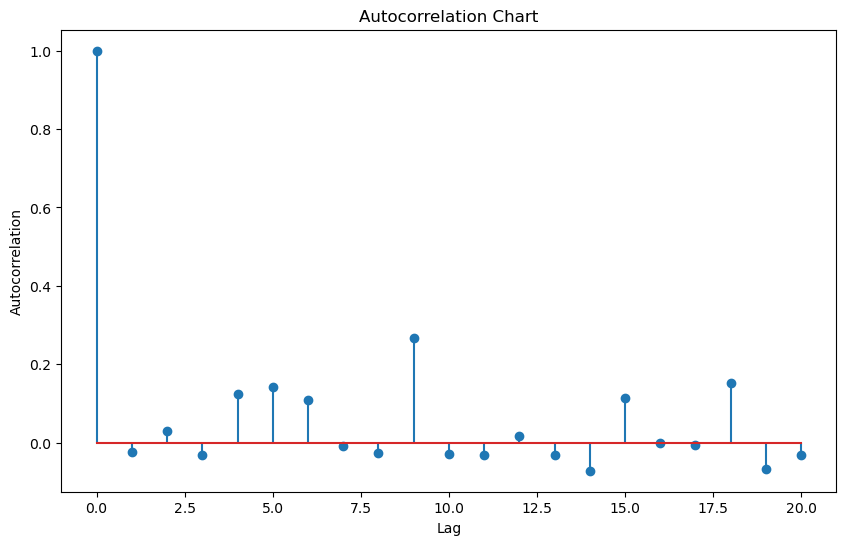

In [77]:
# Compute the autocorrelation
autocorrelation = sm.tsa.acf(dfTrain['sales'], nlags=20)

# Plot the autocorrelation chart
plt.figure(figsize=(10, 6))
plt.stem(range(len(autocorrelation)), autocorrelation)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Chart')
plt.show()

### One-hot encoding

In [78]:
lblEnc = LabelEncoder()
dfTrain['family'] = lblEnc.fit_transform(dfTrain['family'])
X = dfTrain.drop(columns = ['family'])
y = dfTrain['family']

In [79]:
X

,id,store_nbr,onpromotion,Year,Month,Day,sales
date,,,,,,,
2013-01-01,0,1,0,2013,1,1,0.000
2013-01-01,1,1,0,2013,1,1,0.000
2013-01-01,2,1,0,2013,1,1,0.000
2013-01-01,3,1,0,2013,1,1,0.000
2013-01-01,4,1,0,2013,1,1,0.000
...,...,...,...,...,...,...,...
2017-08-15,3000883,9,0,2017,8,15,438.133
2017-08-15,3000884,9,1,2017,8,15,154.553
2017-08-15,3000885,9,148,2017,8,15,2419.729


In [80]:
y

date
2013-01-01     0
2013-01-01     1
2013-01-01     2
2013-01-01     3
2013-01-01     4
              ..
2017-08-15    28
2017-08-15    29
2017-08-15    30
2017-08-15    31
2017-08-15    32
Name: family, Length: 3000888, dtype: int64

### Splitting data

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2, 
                                                    random_state = 42, 
                                                    stratify = y)

# Model creation: ETS and ARIMA

### ETS

In [94]:
model = ets(
    X_train['sales'],
    error = 'add',
    trend = 'add',
    damped_trend = True,
    seasonal = 'add',
    seasonal_periods = 12,
    initialization_method = 'estimated')

In [95]:
modelResult = model.fit(disp = True, maxiter = 10000)

In [96]:
print(modelResult.summary())

                                 ETS Results                                  
Dep. Variable:                  sales   No. Observations:              2400710
Model:                      ETS(AAdA)   Log Likelihood           -20218908.889
Date:                Sat, 04 Apr 2026   AIC                       40437855.778
Time:                        12:39:57   BIC                       40438096.913
Sample:                             0   HQIC                      40437919.894
                            - 2400710   Scale                      1210120.653
Covariance Type:               approx                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
smoothing_level         0.0001    8.3e-05      1.204      0.229   -6.28e-05       0.000
smoothing_trend          1e-08   1.63e-05      0.001      1.000   -3.19e-05    3.19e-05
smoothing_season

In [97]:
forecast = modelResult.forecast(steps = len(dfTest))

In [98]:
forecast

2400710    367.094810
2400711    375.528460
2400712    370.109561
2400713    347.913036
2400714    295.982824
              ...    
2429217    384.050829
2429218    375.978151
2429219    360.824208
2429220    352.456001
2429221    374.376295
Name: simulation, Length: 28512, dtype: float64

In [99]:
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['id']

In [100]:
dfSub['sales'] = list(map(float, forecast))

In [101]:
dfSub

,id,sales
0,3000888,367.094810
1,3000889,375.528460
2,3000890,370.109561
3,3000891,347.913036
4,3000892,295.982824
...,...,...
28507,3029395,384.050829
28508,3029396,375.978151
28509,3029397,360.824208
28510,3029398,352.456001


In [102]:
dfSub.to_csv("submissionEST.csv",
            index = False)

#### Kaggle.com submission leaderboard

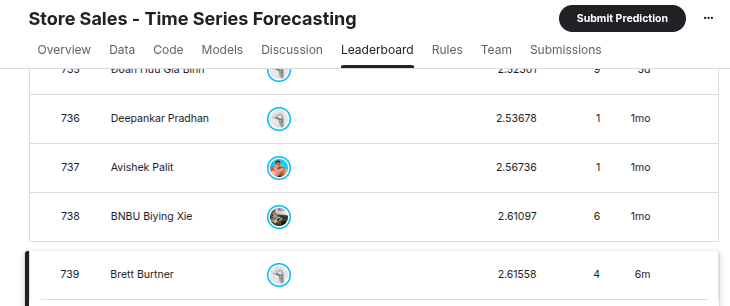

### ARIMA

In [106]:
model = ARIMA(dfTrain['sales'], order = (5, 1, 0))
modelResult = model.fit()

In [108]:
print(modelResult.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:              3000888
Model:                 ARIMA(5, 1, 0)   Log Likelihood           -25325429.958
Date:                Sat, 04 Apr 2026   AIC                       50650871.917
Time:                        13:11:15   BIC                       50650949.403
Sample:                             0   HQIC                      50650892.345
                            - 3000888                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9570      0.000  -2567.755      0.000      -0.958      -0.956
ar.L2         -0.8270      0.000  -2135.223      0.000      -0.828      -0.826
ar.L3         -0.7284      0.000  -2512.384      0.0

In [109]:
forecast = modelResult.forecast(steps = len(dfTest))

In [110]:
forecast

3000888    413.102896
3000889    761.662882
3000890    807.728478
3000891    720.994532
3000892    342.589443
              ...    
3029395    584.487313
3029396    584.487313
3029397    584.487313
3029398    584.487313
3029399    584.487313
Name: predicted_mean, Length: 28512, dtype: float64

In [111]:
dfSub = pd.DataFrame()
dfSub['id'] = dfTest['id']

In [114]:
dfSub['sales'] = list(map(float, forecast))

In [115]:
dfSub

,id,sales
0,3000888,413.102896
1,3000889,761.662882
2,3000890,807.728478
3,3000891,720.994532
4,3000892,342.589443
...,...,...
28507,3029395,584.487313
28508,3029396,584.487313
28509,3029397,584.487313
28510,3029398,584.487313


In [117]:
dfSub.to_csv('submissionARIMA.csv',
             index = False)

In [118]:
dfSub

,id,sales
0,3000888,413.102896
1,3000889,761.662882
2,3000890,807.728478
3,3000891,720.994532
4,3000892,342.589443
...,...,...
28507,3029395,584.487313
28508,3029396,584.487313
28509,3029397,584.487313
28510,3029398,584.487313
